In [2]:
import numpy as np
import matplotlib.pyplot as plt
from part_1.controller import DPController, simulate_error_dynamics

# Parameter tuning

## Error dynamics

In [3]:
def plot_simulation_results(results):
    """
    GEMINI MADE THIS
    Plots position errors, velocity errors, and actuator usage in 3 vertical subplots.
    """
    t = results["time"]
    x = results["state_error"]
    u = results["actuator_usage"]

    # Extract states # and DO NOT convert angles to degrees
    ex, ey, epsi = x[0], x[1], np.rad2deg(x[2])  # x[2]
    eu, ev, er = x[3], x[4], np.rad2deg(x[5])  # x[5]

    # Extract actuator usage and convert to kN and kN·m
    tau_x, tau_y, tau_psi = u[0] / 1000, u[1] / 1000, u[2] / 1000

    # Create 3 vertical subplots sharing the x-axis
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, dpi=100)

    # I recommend explicitly setting colors so the limit lines match the data lines perfectly
    c1, c2, c3 = 'tab:blue', 'tab:orange', 'tab:green'

    # --- Plot 1: Position / Heading Errors ---
    axes[0].plot(t, ex, label=r"$e_x$ [m]", color=c1, linewidth=2)
    axes[0].plot(t, ey, label=r"$e_y$ [m]", color=c2, linewidth=2)
    axes[0].plot(t, epsi, label=r"$e_\psi$ [deg]", color=c3, linewidth=2, linestyle="--")
    axes[0].axhline(0, color="black", linestyle="-", alpha=0.3)
    
    # State Limits: x (5m), y (5m), psi (5 deg)
    axes[0].axhline(5, color='gray', linestyle=":", alpha=0.8, label="Max Limit (5)")
    axes[0].axhline(-5, color='gray', linestyle=":", alpha=0.8)

    # Dynamic ylim based on data ONLY
    max_pos = max(np.max(np.abs(ex)), np.max(np.abs(ey)), np.max(np.abs(epsi)), 0.1)
    axes[0].set_ylim(-max_pos * 1.1, max_pos * 1.1)

    axes[0].set_title("Position and Heading Errors")
    axes[0].set_ylabel("Error")
    axes[0].grid(True, linestyle="--", alpha=0.7)
    # Move legend to avoid overlapping lines
    axes[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    # --- Plot 2: Velocity Errors ---
    axes[1].plot(t, eu, label=r"$e_u$ [m/s]", color=c1, linewidth=2)
    axes[1].plot(t, ev, label=r"$e_v$ [m/s]", color=c2, linewidth=2)
    axes[1].plot(t, er, label=r"$e_r$ [deg/s]", color=c3, linewidth=2, linestyle="--")
    axes[1].axhline(0, color="black", linestyle="-", alpha=0.3)

    # Velocity Limits: u,v (0.5 m/s), r (0.1 rad/s -> converted to deg/s)
    r_lim_deg = np.rad2deg(0.1)
    axes[1].axhline(0.5, color=c1, linestyle=":", alpha=0.6, label="Max $u, v$ (0.5)")
    axes[1].axhline(-0.5, color=c1, linestyle=":", alpha=0.6)
    axes[1].axhline(r_lim_deg, color=c3, linestyle=":", alpha=0.6, label=f"Max $r$ ({r_lim_deg:.1f})")
    axes[1].axhline(-r_lim_deg, color=c3, linestyle=":", alpha=0.6)

    # Dynamic ylim based on data ONLY
    max_vel = max(np.max(np.abs(eu)), np.max(np.abs(ev)), np.max(np.abs(er)), 0.01)
    axes[1].set_ylim(-max_vel * 1.1, max_vel * 1.1)

    axes[1].set_title("Velocity Errors")
    axes[1].set_ylabel("Error")
    axes[1].grid(True, linestyle="--", alpha=0.7)
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    # --- Plot 3: Actuator Usage ---
    axes[2].plot(t, tau_x, label=r"$\tau_x$ [kN]", color=c1, linewidth=2)
    axes[2].plot(t, tau_y, label=r"$\tau_y$ [kN]", color=c2, linewidth=2)
    axes[2].plot(t, tau_psi, label=r"$\tau_\psi$ [kN·m]", color=c3, linewidth=2, linestyle="--")
    axes[2].axhline(0, color="black", linestyle="-", alpha=0.3)

    # Actuator Limits
    axes[2].axhline(160, color=c1, linestyle=":", alpha=0.6, label=r"Max $\tau_x$ (160)")
    axes[2].axhline(-160, color=c1, linestyle=":", alpha=0.6)
    axes[2].axhline(112, color=c2, linestyle=":", alpha=0.6, label=r"Max $\tau_y$ (112)")
    axes[2].axhline(-112, color=c2, linestyle=":", alpha=0.6)
    axes[2].axhline(1424, color=c3, linestyle=":", alpha=0.6, label=r"Max $\tau_\psi$ (1424)")
    axes[2].axhline(-1424, color=c3, linestyle=":", alpha=0.6)

    # Dynamic ylim based on data ONLY
    max_tau = max(np.max(np.abs(tau_x)), np.max(np.abs(tau_y)), np.max(np.abs(tau_psi)), 1.0)
    axes[2].set_ylim(-max_tau * 1.1, max_tau * 1.1)

    axes[2].set_title("Actuator Usage (Control Input)")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel("Force / Moment")
    axes[2].grid(True, linestyle="--", alpha=0.7)
    axes[2].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    plt.tight_layout()
    plt.show()


def plot_scalar_metrics(scalar_metrics_dict):
    """
    GEMINI MADE THIS
    Plots single-number performance metrics (IAE, ISE) as bar charts.
    """
    n_metrics = len(scalar_metrics_dict)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 3.5 * n_metrics), dpi=100)

    if n_metrics == 1:
        axes = [axes]

    state_labels = [r"$e_x$", r"$e_y$", r"$e_\psi$", r"$e_u$", r"$e_v$", r"$e_r$"]

    for ax, (metric_name, metric_values) in zip(axes, scalar_metrics_dict.items()):
        bars = ax.bar(state_labels, metric_values, color="skyblue", edgecolor="black")

        for bar in bars:
            yval = bar.get_height()
            val_str = f"{yval:.2e}" if yval > 1e4 or yval < 1e-2 else f"{yval:.2f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval,
                val_str,
                ha="center",
                va="bottom",
                fontsize=9,
            )

        ax.set_title(f"Performance Metric: {metric_name}")
        ax.set_ylabel("Metric Value")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_timeseries_metrics(time_array, ts_metrics_dict):
    """
    GEMINI MADE THIS
    Plots cumulative performance metrics as continuous time series.
    """
    n_metrics = len(ts_metrics_dict)
    fig, axes = plt.subplots(
        n_metrics, 1, figsize=(12, 3 * n_metrics), sharex=True, dpi=100
    )

    if n_metrics == 1:
        axes = [axes]

    labels = [r"$e_x$", r"$e_y$", r"$e_\psi$", r"$e_u$", r"$e_v$", r"$e_r$"]
    linestyles = ["-", "-", "-", "--", "--", "--"]

    for ax, (metric_name, metric_data) in zip(axes, ts_metrics_dict.items()):
        for i in range(6):
            ax.plot(
                time_array,
                metric_data[i, :],
                label=labels[i],
                linestyle=linestyles[i],
                linewidth=2,
            )

        ax.set_title(f"{metric_name} Over Time")
        ax.set_ylabel("Metric Value")
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()

[-0.20932187+0.j         -0.04600109+0.01933133j -0.04600109-0.01933133j
 -0.21331984+0.17353881j -0.21331984-0.17353881j -0.17631808+0.j
 -0.04458655+0.02204874j -0.04458655-0.02204874j -0.0276993 +0.j        ]


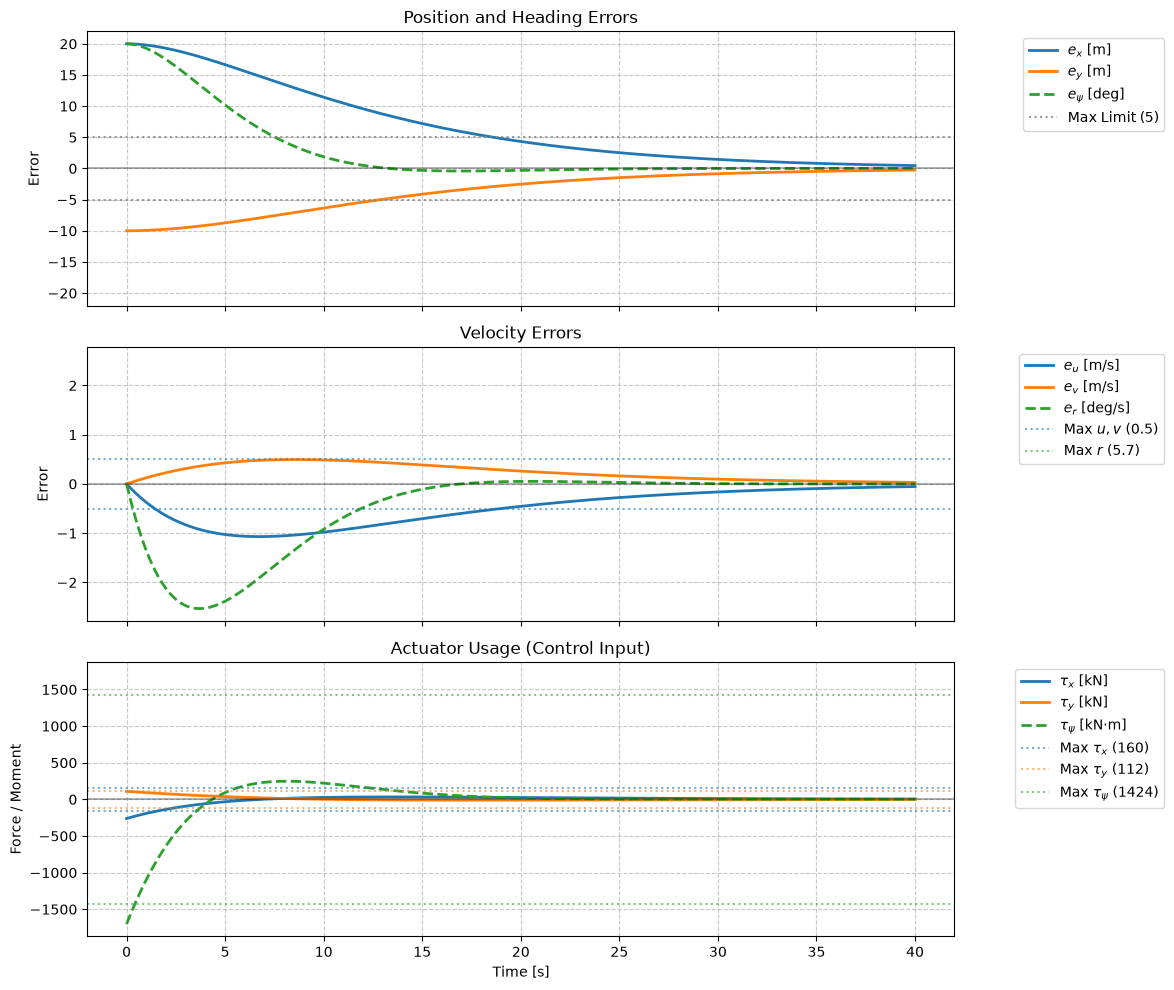

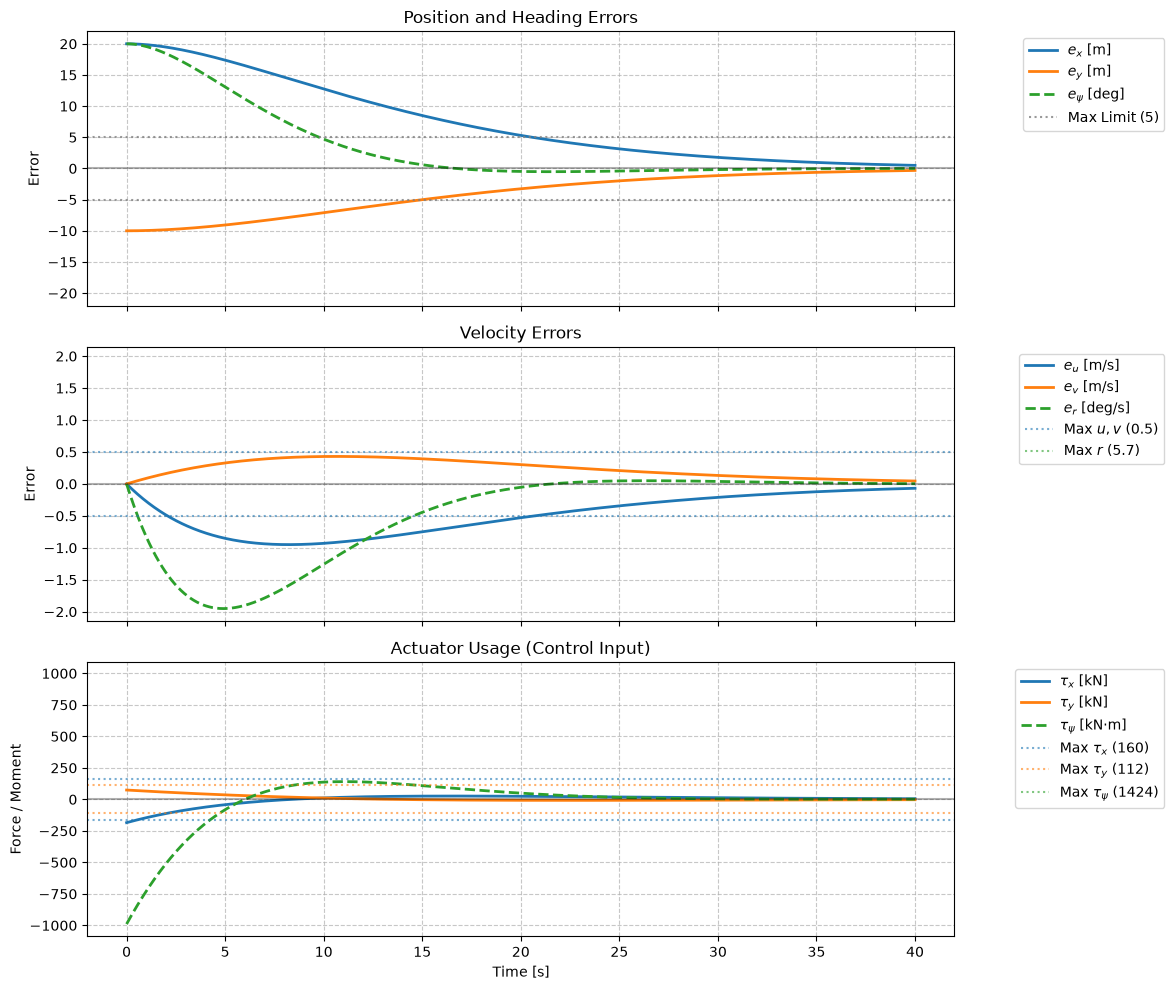

In [17]:
x0_surge = 20  # m
x0_sway = -10  # m
x0_yaw = 20 * np.pi / 180  # rad
x0_vel_surge = 0  # m/s
x0_vel_sway = 0  # m/s
x0_vel_yaw = 0 * np.pi / 180  # rad/s


x0 = np.array([x0_surge, x0_sway, x0_yaw, x0_vel_surge, x0_vel_sway, x0_vel_yaw])

controller1 = DPController()

# Q matrix penalizes position (0:3) and velocity (3:6) errors
# R penalizes actuator usage

# print(controller1.LQR_cl_eigenvalues())
print(controller1.augmented_eigenvalues())


# Controller 2 er ganske bra
Q2 = np.diag([0.04, 0.04, 131.31, 4, 4, 100 * 2])
R2 = np.diag([3.90625000e-11 * 6, 7.97193878e-11 * 3, 4.93151117e-13 * 4])
controller2 = DPController(Q=Q2, R=R2)

# Controller 3 er bedre tror jeg
Q3 = np.diag([0.04, 0.04, 131.31, 4, 4, 100 * 5])
R3 = np.diag([3.90625000e-11 * 12, 7.97193878e-11 * 6, 4.93151117e-13 * 36])

controller3 = DPController(Q=Q3, R=R3)
# print(controller3.LQR_cl_eigenvalues())
# print(controller3.augmented_eigenvalues())
# print(max(abs(np.real(controller3.LQR_cl_eigenvalues()))))
# print(1/max(abs(np.real(controller3.LQR_cl_eigenvalues()))))


# --- Usage ---
# print(f"IAE for Position X: {results['metrics']['IAE'][0]:.2f}")
# print(f"ISE for Position Y: {results['metrics']['ISE'][1]:.2f}")
# 1. Run simulation
results1 = simulate_error_dynamics(controller1, x0, t_end=40)
results2 = simulate_error_dynamics(controller2, x0, t_end=40)
results3 = simulate_error_dynamics(controller3, x0, t_end=40)

time = results1["time"]
ex, ey, epsi = results1["state_error"][0:3]
tau_x, tau_y, tau_psi = results1["actuator_usage"]

# 2. Plot states and actuators (using your existing plot_simulation_results function)
plot_simulation_results(results1)
# plot_simulation_results(results2)
plot_simulation_results(results3)

# # 3. Create a dictionary for scalar metrics and plot
# scalar_dict = {"IAE": results["metrics"]["IAE"], "ISE": results["metrics"]["ISE"]}
# plot_scalar_metrics(scalar_dict)

# 4. Create a dictionary for time-series metrics and plot
# ts_dict = {
#     "Cumulative IAE": results1["metrics"]["Cumulative IAE"],
#     "Cumulative ISE": results1["metrics"]["Cumulative ISE"],
# }
# plot_timeseries_metrics(results1["time"], ts_dict)